# Chapter 26 — Matrices as Tables of Numbers

In Chapter 25, we represented a vector as an ordered list of numbers.

This chapter introduces a **matrix**: a rectangular table of numbers.

In Python, we will represent a matrix as a list of row lists.

All calculations still use plain Python lists and loops, with no NumPy or PyTorch yet.

## Learning goals

By the end of this chapter, you should be able to:

1. Explain what a matrix is.
2. Represent a matrix as a list of lists in Python.
3. Identify its number of rows and columns.
4. Select a row, column, or individual entry.
5. Explain matrix shape and the meaning of each axis.
6. Validate that a matrix is rectangular and numeric.
7. Implement matrix-vector multiplication manually.
8. Explain its input and output shape rule.
9. Draw and interpret a labeled matrix heatmap.
10. Explain how matrices appear later in language models.

## What is a matrix?

A matrix is a rectangular table of numbers arranged into rows and columns.

This matrix has two rows and three columns:

```text
1   2   3
4   5   6
```

Its shape is written `2 × 3`, read as “2 rows by 3 columns.”

In [1]:
matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
]

print("Matrix as a Python object:")
print(matrix)

print()
print("Matrix row by row:")

for row in matrix:
    print(row)

Matrix as a Python object:
[[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]

Matrix row by row:
[1.0, 2.0, 3.0]
[4.0, 5.0, 6.0]


Each inner list is one row vector.

The outer list stores those rows in order.

## Rows, columns, entries, and shape

A **row** is a horizontal list of entries, and a **column** is a vertical list of entries.

A **matrix entry** is one number selected by a row index and a column index.

The **shape** is always written as `number of rows × number of columns`.

In [2]:
number_of_rows = len(matrix)
number_of_columns = len(matrix[0])

print("Number of rows:", number_of_rows)
print("Number of columns:", number_of_columns)
print(f"Shape: {number_of_rows} × {number_of_columns}")

Number of rows: 2
Number of columns: 3
Shape: 2 × 3


The outer-list length gives the number of rows.

For a rectangular matrix, every row has the same length, so one row's length gives the number of columns.

We should validate that assumption before relying on it.

## Validate rectangular numeric matrices

A proper matrix must have at least one row, at least one column, equal row lengths, and numeric entries.

As in Chapter 25, the runtime checks reject booleans so they do not silently act like the integers 0 and 1.

In [3]:
from collections.abc import Sequence


def assert_matrix_of_numbers(matrix: Sequence[Sequence[object]]) -> None:
    if len(matrix) == 0:
        raise ValueError("A matrix must contain at least one row.")

    number_of_columns = len(matrix[0])

    if number_of_columns == 0:
        raise ValueError("A matrix must contain at least one column.")

    for row_index, row in enumerate(matrix):
        if len(row) != number_of_columns:
            raise ValueError(
                "Every row must have the same number of columns. "
                f"Row 0 has {number_of_columns}, but row {row_index} has {len(row)}."
            )

        for column_index, entry in enumerate(row):
            is_number = isinstance(entry, (int, float))

            if not is_number or isinstance(entry, bool):
                raise TypeError(
                    f"Entry at row {row_index}, column {column_index} "
                    f"must be an int or float. Received {entry!r}."
                )


def get_matrix_shape(matrix: Sequence[Sequence[object]]) -> tuple[int, int]:
    assert_matrix_of_numbers(matrix)

    return len(matrix), len(matrix[0])

In [4]:
matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
]

number_of_rows, number_of_columns = get_matrix_shape(matrix)

print("Number of rows:", number_of_rows)
print("Number of columns:", number_of_columns)
print(f"Shape: {number_of_rows} × {number_of_columns}")

assert (number_of_rows, number_of_columns) == (2, 3)

Number of rows: 2
Number of columns: 3
Shape: 2 × 3


### A ragged list is not a rectangular matrix

The next example has rows of different lengths, so it does not have one well-defined column count.

In [5]:
ragged_matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0],
]

try:
    get_matrix_shape(ragged_matrix)
except ValueError as error:
    print("Caught expected error:")
    print(error)

Caught expected error:
Every row must have the same number of columns. Row 0 has 3, but row 1 has 2.


Rejecting ragged data early prevents later code from silently assuming a column exists when it does not.

## Select rows and entries

Selecting one index from the outer list returns a whole row.

Selecting a second index returns one entry from that row.

In [6]:
matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
]

first_row = matrix[0]
second_row = matrix[1]
selected_entry = matrix[1][2]

print("Row 0:", first_row)
print("Row 1:", second_row)
print("Entry at row 1, column 2:", selected_entry)

Row 0: [1.0, 2.0, 3.0]
Row 1: [4.0, 5.0, 6.0]
Entry at row 1, column 2: 6.0


Python indexes start at 0.

Therefore, `matrix[1][2]` selects the second row and then the third entry in that row.

In [7]:
for row_index, row in enumerate(matrix):
    for column_index, entry in enumerate(row):
        print(f"row {row_index}, column {column_index}: {entry}")

row 0, column 0: 1.0
row 0, column 1: 2.0
row 0, column 2: 3.0
row 1, column 0: 4.0
row 1, column 1: 5.0
row 1, column 2: 6.0


The nested loops expose the two independent positions needed to locate each entry.

## Select a column

Because the Python representation is organized by rows, selecting a column requires collecting one entry from every row.

This course helper uses nonnegative indexes explicitly instead of Python's negative-index shorthand.

In [8]:
def get_matrix_column(
    matrix: list[list[float]],
    column_index: int,
) -> list[float]:
    _, number_of_columns = get_matrix_shape(matrix)

    if column_index < 0 or column_index >= number_of_columns:
        raise ValueError(f"column_index must be between 0 and {number_of_columns - 1}.")

    column = []

    for row in matrix:
        column.append(row[column_index])

    return column

In [9]:
first_column = get_matrix_column(matrix, 0)
second_column = get_matrix_column(matrix, 1)
third_column = get_matrix_column(matrix, 2)

print("Column 0:", first_column)
print("Column 1:", second_column)
print("Column 2:", third_column)

assert first_column == [1.0, 4.0]
assert second_column == [2.0, 5.0]
assert third_column == [3.0, 6.0]

Column 0: [1.0, 4.0]
Column 1: [2.0, 5.0]
Column 2: [3.0, 6.0]


Rows and columns are different views of the same table.

For this `2 × 3` matrix, each row has length 3 and each column has length 2.

## Print a matrix clearly

A small helper can report the shape before printing each row.

In [10]:
def print_matrix(matrix: list[list[float]]) -> None:
    number_of_rows, number_of_columns = get_matrix_shape(matrix)

    print(f"shape: {number_of_rows} × {number_of_columns}")
    print("-" * 24)

    for row in matrix:
        print(row)

In [11]:
print_matrix(matrix)

shape: 2 × 3
------------------------
[1.0, 2.0, 3.0]
[4.0, 5.0, 6.0]


Shape is essential, but it does not explain what either axis represents.

We must also attach meaning to the rows and columns.

## Shape meanings in language models

The same raw shape can represent different concepts.

Common examples include:

- a bigram table shaped `vocabulary size × vocabulary size`, with previous tokens as rows and next tokens as columns;
- an embedding table shaped `vocabulary size × embedding dimension`, with token IDs as rows and embedding coordinates as columns;
- a token batch shaped `batch size × sequence length`, with examples as rows and token positions as columns;
- hidden states shaped `sequence length × hidden dimension`, with token positions as rows and hidden coordinates as columns;
- attention scores shaped `sequence length × sequence length`, with query positions as rows and key positions as columns.

A `4 × 6` matrix could mean four tokens by six embedding coordinates or four examples by six features.

The shape is identical, but the interpretation is not.

Descriptive names and axis labels help prevent shape confusion.

In [12]:
batch_token_id_matrix = [
    [101.0, 102.0, 103.0, 104.0],
    [201.0, 202.0, 203.0, 204.0],
]

batch_size, sequence_length = get_matrix_shape(batch_token_id_matrix)

print("Rows mean examples in the batch.")
print("Columns mean token positions.")
print("Batch size:", batch_size)
print("Sequence length:", sequence_length)

Rows mean examples in the batch.
Columns mean token positions.
Batch size: 2
Sequence length: 4


The variable names connect each dimension to its role.

Real token IDs are integers, but floating-point values are used throughout this chapter so the same matrix helpers work consistently in later numerical examples.

## Matrix-vector multiplication

Matrix-vector multiplication takes a matrix and a vector and returns a new vector.

Each output coordinate is the dot product of one matrix row with the input vector.

For a matrix shaped `rows × columns`, the input vector must have length `columns`, and the output vector has length `rows`.

For the matrix `[[1, 2, 3], [4, 5, 6]]` and vector `[10, 20, 30]`, the two row dot products are `140` and `320`.

We will first restore the vector checks and dot product from Chapter 25.

In [13]:
def assert_vector_of_numbers(vector: Sequence[object]) -> None:
    if len(vector) == 0:
        raise ValueError("A vector must contain at least one number.")

    for position, coordinate in enumerate(vector):
        is_number = isinstance(coordinate, (int, float))

        if not is_number or isinstance(coordinate, bool):
            raise TypeError(
                f"Coordinate at position {position} must be an int or float. "
                f"Received {coordinate!r}."
            )


def assert_same_dimension(
    first_vector: list[float],
    second_vector: list[float],
) -> None:
    assert_vector_of_numbers(first_vector)
    assert_vector_of_numbers(second_vector)

    if len(first_vector) != len(second_vector):
        raise ValueError(
            "Vectors must have the same dimension. "
            f"Received dimensions {len(first_vector)} and {len(second_vector)}."
        )


def dot_product(
    first_vector: list[float],
    second_vector: list[float],
) -> float:
    assert_same_dimension(first_vector, second_vector)

    total = 0.0

    for position in range(len(first_vector)):
        total = total + first_vector[position] * second_vector[position]

    return total

In [14]:
dot_product_result = dot_product(
    first_vector=[1.0, 2.0, 3.0],
    second_vector=[10.0, 20.0, 30.0],
)

print("Dot product:", dot_product_result)

assert dot_product_result == 140.0

Dot product: 140.0


### Implement matrix-vector multiplication

The function validates the shapes, takes one dot product per row, and appends each scalar result to the output vector.

In [15]:
def multiply_matrix_by_vector(
    matrix: list[list[float]],
    vector: list[float],
) -> list[float]:
    _, number_of_columns = get_matrix_shape(matrix)
    assert_vector_of_numbers(vector)

    if len(vector) != number_of_columns:
        raise ValueError(
            "Matrix-vector multiplication shape mismatch. "
            f"Matrix has {number_of_columns} columns, "
            f"but vector has length {len(vector)}."
        )

    result = []

    for row in matrix:
        result.append(dot_product(row, vector))

    return result

In [16]:
matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
]
vector = [10.0, 20.0, 30.0]

matrix_vector_product = multiply_matrix_by_vector(matrix, vector)

print("Matrix:")
print_matrix(matrix)
print("Input vector:", vector)
print("Output vector:", matrix_vector_product)

assert matrix_vector_product == [140.0, 320.0]

Matrix:
shape: 2 × 3
------------------------
[1.0, 2.0, 3.0]
[4.0, 5.0, 6.0]
Input vector: [10.0, 20.0, 30.0]
Output vector: [140.0, 320.0]


The three matrix columns match the input dimension of 3.

The two matrix rows produce an output dimension of 2.

### Print every multiplication step

The traced version makes each row-to-output-coordinate calculation visible.

In [17]:
def print_matrix_vector_multiplication_steps(
    matrix: list[list[float]],
    vector: list[float],
) -> list[float]:
    number_of_rows, number_of_columns = get_matrix_shape(matrix)
    assert_vector_of_numbers(vector)

    if len(vector) != number_of_columns:
        raise ValueError(
            "Matrix-vector multiplication shape mismatch. "
            f"Matrix has {number_of_columns} columns, "
            f"but vector has length {len(vector)}."
        )

    result = []

    print("Matrix-vector multiplication")
    print("-" * 48)
    print(f"Matrix shape: {number_of_rows} × {number_of_columns}")
    print("Input vector length:", len(vector))
    print("Expected output length:", number_of_rows)
    print()

    for row_index, row in enumerate(matrix):
        products = []
        total = 0.0

        print(f"Output coordinate {row_index} from row {row_index}")

        for column_index in range(number_of_columns):
            product = row[column_index] * vector[column_index]
            products.append(product)
            total = total + product

            print(
                f"  column {column_index}: "
                f"{row[column_index]} × {vector[column_index]} = {product}"
            )

        print("  products:", products)
        print("  sum:", total)
        print()
        result.append(total)

    print("Final output vector:", result)

    return result

In [18]:
traced_product = print_matrix_vector_multiplication_steps(
    matrix=matrix,
    vector=vector,
)

assert traced_product == [140.0, 320.0]

Matrix-vector multiplication
------------------------------------------------
Matrix shape: 2 × 3
Input vector length: 3
Expected output length: 2

Output coordinate 0 from row 0
  column 0: 1.0 × 10.0 = 10.0
  column 1: 2.0 × 20.0 = 40.0
  column 2: 3.0 × 30.0 = 90.0
  products: [10.0, 40.0, 90.0]
  sum: 140.0

Output coordinate 1 from row 1
  column 0: 4.0 × 10.0 = 40.0
  column 1: 5.0 × 20.0 = 100.0
  column 2: 6.0 × 30.0 = 180.0
  products: [40.0, 100.0, 180.0]
  sum: 320.0

Final output vector: [140.0, 320.0]


Each row contributes exactly one coordinate to the output vector.

This is the manual form of a fundamental neural-network operation.

### A shape mismatch cannot produce row dot products

If the matrix has three columns but the vector has only two coordinates, each row and the vector have different dimensions.

In [19]:
bad_vector = [10.0, 20.0]

try:
    multiply_matrix_by_vector(matrix, bad_vector)
except ValueError as error:
    print("Caught expected error:")
    print(error)

Caught expected error:
Matrix-vector multiplication shape mismatch. Matrix has 3 columns, but vector has length 2.


The explicit error reports both dimensions instead of allowing a partial or ambiguous calculation.

## A parameter matrix changes vector dimension

A matrix can be viewed as a collection of parameter-row vectors.

Each parameter row produces one output score, so changing the row count changes the output dimension.

In [20]:
parameter_matrix = [
    [0.2, -0.5, 1.0],
    [1.5, 0.3, -0.2],
    [-0.7, 0.8, 0.1],
    [0.4, 0.6, -0.3],
]
input_vector = [2.0, -1.0, 0.5]

output_vector = multiply_matrix_by_vector(parameter_matrix, input_vector)
matrix_shape = get_matrix_shape(parameter_matrix)

print("Parameter matrix shape:", matrix_shape)
print("Input dimension:", len(input_vector))
print("Output dimension:", len(output_vector))
print("Output vector:", output_vector)

Parameter matrix shape: (4, 3)
Input dimension: 3
Output dimension: 4
Output vector: [1.4, 2.6, -2.1500000000000004, 0.05000000000000007]


The `4 × 3` matrix accepts a 3D input vector and produces a 4D output vector.

This resembles part of a linear layer, although a full linear layer will also introduce a bias vector later.

## Embedding tables are matrices

In an embedding table, rows represent token IDs and columns represent embedding coordinates.

Selecting a token ID selects one row vector.

In [21]:
tiny_vocabulary = ["cat", "dog", "mat", "rug"]
embedding_table = [
    [0.2, 0.8, -0.1],
    [0.3, 0.7, -0.2],
    [-0.5, 0.1, 0.9],
    [-0.4, 0.2, 0.8],
]
token_to_id = {token: token_id for token_id, token in enumerate(tiny_vocabulary)}

token = "dog"
token_id = token_to_id[token]
selected_embedding = embedding_table[token_id]

print("Embedding table shape:", get_matrix_shape(embedding_table))
print("Rows mean token IDs.")
print("Columns mean embedding coordinates.")
print("Selected token:", token)
print("Selected token ID:", token_id)
print("Selected embedding:", selected_embedding)

Embedding table shape: (4, 3)
Rows mean token IDs.
Columns mean embedding coordinates.
Selected token: dog
Selected token ID: 1
Selected embedding: [0.3, 0.7, -0.2]


This toy table has shape `4 × 3`: four token rows and three learned-coordinate positions per token.

The numbers are illustrative rather than learned by a real model.

## Bigram count tables are matrices

In a bigram count table, rows represent previous tokens and columns represent next tokens.

The entry at `[previous_token_id][next_token_id]` stores the corresponding transition count.

In [22]:
tiny_characters = ["a", "b", "c"]
bigram_count_table = [
    [0.0, 2.0, 1.0],
    [3.0, 0.0, 1.0],
    [1.0, 1.0, 0.0],
]
character_to_id = {
    character: character_id for character_id, character in enumerate(tiny_characters)
}

previous_character = "b"
next_character = "a"
previous_id = character_to_id[previous_character]
next_id = character_to_id[next_character]
transition_count = bigram_count_table[previous_id][next_id]

print("Bigram table shape:", get_matrix_shape(bigram_count_table))
print("Rows mean previous characters.")
print("Columns mean next characters.")
print(f"Count for {previous_character!r} followed by {next_character!r}:")
print(transition_count)

Bigram table shape: (3, 3)
Rows mean previous characters.
Columns mean next characters.
Count for 'b' followed by 'a':
3.0


The table has shape `vocabulary size × vocabulary size`, which is `3 × 3` here.

The selected value says that `"a"` followed `"b"` three times in this toy count table.

## Draw and interpret matrix heatmaps

A heatmap represents each matrix entry with a color.

The two panels below use matrices with the same `3 × 3` shape but different axis meanings.

Labels are therefore part of the explanation, not decoration.

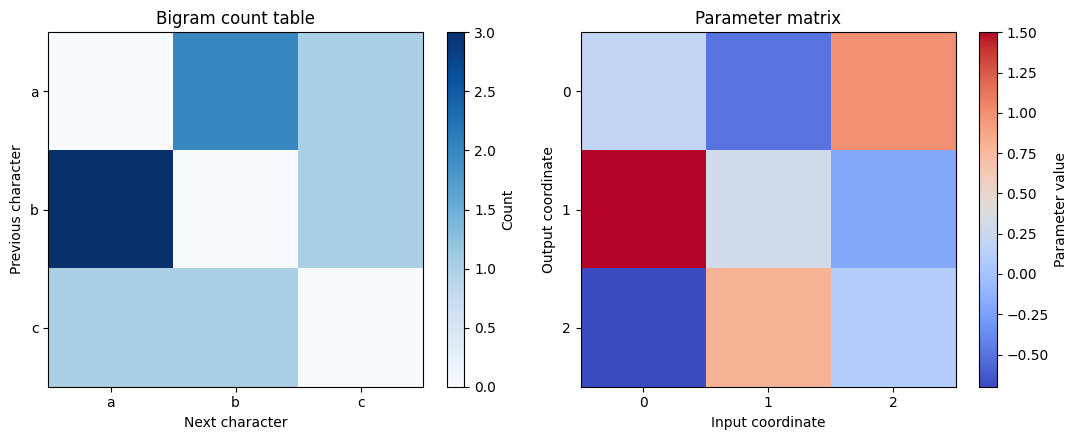

In [23]:
import matplotlib.pyplot as plt

heatmap_parameter_matrix = [
    [0.2, -0.5, 1.0],
    [1.5, 0.3, -0.2],
    [-0.7, 0.8, 0.1],
]

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))

count_image = axes[0].imshow(bigram_count_table, aspect="auto", cmap="Blues")
axes[0].set_title("Bigram count table")
axes[0].set_xlabel("Next character")
axes[0].set_ylabel("Previous character")
axes[0].set_xticks(range(len(tiny_characters)), labels=tiny_characters)
axes[0].set_yticks(range(len(tiny_characters)), labels=tiny_characters)
figure.colorbar(count_image, ax=axes[0], label="Count")

parameter_image = axes[1].imshow(
    heatmap_parameter_matrix,
    aspect="auto",
    cmap="coolwarm",
)
axes[1].set_title("Parameter matrix")
axes[1].set_xlabel("Input coordinate")
axes[1].set_ylabel("Output coordinate")
axes[1].set_xticks(range(3))
axes[1].set_yticks(range(3))
figure.colorbar(parameter_image, ax=axes[1], label="Parameter value")

plt.tight_layout()
plt.show()

The left panel uses rows and columns as token identities, while the right panel uses them as output and input coordinates.

Color intensity makes value patterns visible, but the axes determine what those patterns mean.

## Catch other invalid matrices

The same validator catches empty matrices, empty rows, nonnumeric entries, and boolean entries.

In [24]:
invalid_matrices: list[list[list[object]]] = [
    [],
    [[]],
    [[1.0, 2.0], [3.0]],
    [[1.0, "two"], [3.0, 4.0]],
    [[1.0, True], [3.0, 4.0]],
]

for invalid_matrix in invalid_matrices:
    try:
        assert_matrix_of_numbers(invalid_matrix)
    except (TypeError, ValueError) as error:
        print(f"{invalid_matrix!r} -> {error}")

[] -> A matrix must contain at least one row.
[[]] -> A matrix must contain at least one column.
[[1.0, 2.0], [3.0]] -> Every row must have the same number of columns. Row 0 has 2, but row 1 has 1.
[[1.0, 'two'], [3.0, 4.0]] -> Entry at row 0, column 1 must be an int or float. Received 'two'.
[[1.0, True], [3.0, 4.0]] -> Entry at row 0, column 1 must be an int or float. Received True.


Failing near the source of malformed data is easier to debug than failing inside a later matrix operation.

## A clean matrix pipeline

This final example inspects a matrix, selects a row and column, and performs a compatible matrix-vector multiplication.

In [25]:
matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
]
vector = [10.0, 20.0, 30.0]

number_of_rows, number_of_columns = get_matrix_shape(matrix)
selected_row_index = 1
selected_column_index = 2
selected_row = matrix[selected_row_index]
selected_column = get_matrix_column(matrix, selected_column_index)
matrix_vector_product = multiply_matrix_by_vector(matrix, vector)

print("Matrix operations summary")
print("-" * 48)
print_matrix(matrix)
print("Rows:", number_of_rows)
print("Columns:", number_of_columns)
print(f"Row {selected_row_index}:", selected_row)
print(f"Column {selected_column_index}:", selected_column)
print("Input vector:", vector)
print("Matrix-vector product:", matrix_vector_product)

assert selected_row == [4.0, 5.0, 6.0]
assert selected_column == [3.0, 6.0]
assert matrix_vector_product == [140.0, 320.0]

Matrix operations summary
------------------------------------------------
shape: 2 × 3
------------------------
[1.0, 2.0, 3.0]
[4.0, 5.0, 6.0]
Rows: 2
Columns: 3
Row 1: [4.0, 5.0, 6.0]
Column 2: [3.0, 6.0]
Input vector: [10.0, 20.0, 30.0]
Matrix-vector product: [140.0, 320.0]


## What not to do

- Do not treat a matrix as an unlabeled pile of numbers.
- Do not ignore which meanings belong to rows and columns.
- Do not swap axes and assume the interpretation stays the same.
- Do not create ragged matrices with unequal row lengths.
- Do not multiply a matrix by a vector whose length differs from the matrix's column count.
- Do not draw a heatmap without meaningful axis labels.
- Do not use NumPy yet, because the plain loops reveal the operation's structure.

## Gotchas

A matrix is rectangular, and shape is always written as rows by columns.

Selecting a row uses one outer-list index, while selecting a column gathers one entry from every row.

For matrix-vector multiplication, matrix columns must equal input-vector length.

The output length equals the matrix row count.

The same shape can carry different meanings, so descriptive names and labeled axes matter.

## Takeaways

A matrix is a rectangular table represented in plain Python as a list of row lists.

The matrix `[[1, 2, 3], [4, 5, 6]]` has shape `2 × 3`: two rows and three columns.

Matrices can represent bigram counts, embedding tables, parameter tables, token batches, hidden states, attention scores, and model outputs.

Matrix-vector multiplication takes one dot product per matrix row, turning an input vector with length equal to the column count into an output vector with length equal to the row count.

Always track both the size and meaning of every dimension.

## What comes next

The next chapter introduces matrix multiplication.

Matrix multiplication can be understood as applying related dot-product calculations across two matrices.

That operation will prepare us for linear layers, batches, and later attention calculations.